In [1]:
''' Package import test '''
import os
import random
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
from scipy import stats
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

RANDOM_SEED = 4

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

import warnings
warnings.simplefilter('ignore')

print("Package import test successful!")

Package import test successful!


(array([1., 0., 2., 0., 1., 1., 0., 3., 0., 3.]),
 array([0.00623026, 0.10323468, 0.2002391 , 0.29724352, 0.39424794,
        0.49125235, 0.58825677, 0.68526119, 0.78226561, 0.87927003,
        0.97627445]),
 <BarContainer object of 10 artists>)

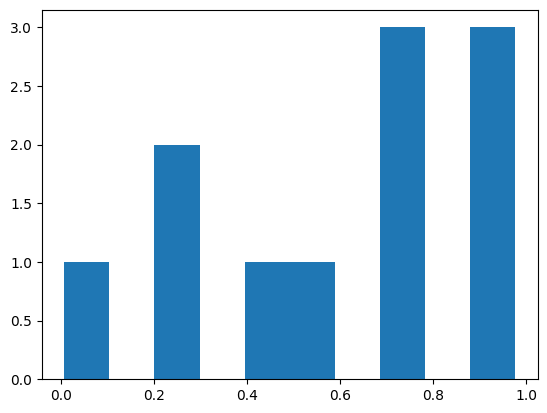

In [2]:
X = np.random.rand(10, 11)

plt.hist(X[0, :])

In [3]:
X.shape

(10, 11)

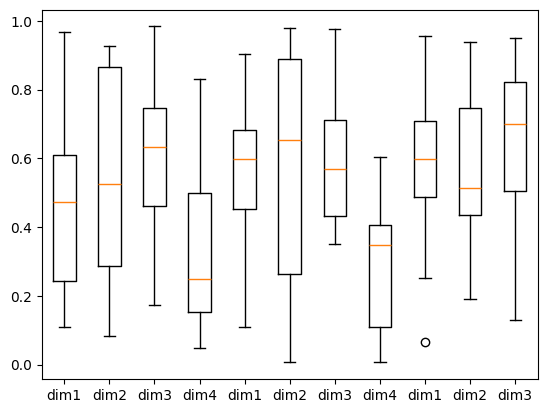

In [4]:
plt.boxplot(X, labels=['dim1', 'dim2', 'dim3', 'dim4', 'dim1', 'dim2', 'dim3', 'dim4', 'dim1', 'dim2', 'dim3'])
# plt.xticks(range(11))
plt.show()

In [5]:
data = [{'name': 'gal', 'age': 10, 'money': 200, 'married': False}, {'name': 'alenka', 'age': 30, 'money': 1000, 'married': True}]

df = pd.DataFrame(data)
display(df)

print(df.size)

g = df.groupby('married').agg(age_mean=('age','mean'), age_sem=('age','max'))
g.sort_index(ascending=False, inplace=True)

display(g)

g2 = df.groupby('married').size()
g2.loc[True] = 20


g.sort_index(inplace=True)
g2.sort_index(inplace=True)

g['total'] = g2

for i, row in g.iterrows():
    print(i)
    print(row)

g.reset_index(inplace=True)
display(g)

print(type(g), type(g2))

,name,age,money,married
0,gal,10,200,False
1,alenka,30,1000,True


8


,age_mean,age_sem
married,,
True,30.0,30
False,10.0,10


False
age_mean    10.0
age_sem     10.0
total        1.0
Name: False, dtype: float64
True
age_mean    30.0
age_sem     30.0
total       20.0
Name: True, dtype: float64


,married,age_mean,age_sem,total
0,False,10.0,10,1
1,True,30.0,30,20


<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


In [6]:
EXCLUDE_CHARS = ['ga', 'al', 'mu']
df['name'] = df['name'].str.replace('|'.join(EXCLUDE_CHARS), ' ', regex=True)

In [7]:
df

,name,age,money,married
0,l,10,200,False
1,enka,30,1000,True


In [8]:
df.sort_index(ascending=False, inplace=True)
df

,name,age,money,married
1,enka,30,1000,True
0,l,10,200,False


In [9]:
X = np.random.rand(2, 10)
ddf = pd.DataFrame(X)
ddf.columns = [f'd_{i}' for i in range(10)]

g = pd.concat([g, ddf], axis=1)

g

,married,age_mean,age_sem,total,d_0,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9
0,False,10.0,10,1,0.347451,0.058880,0.611822,0.124015,0.759530,0.794423,0.408627,0.943798,0.173780,0.942586
1,True,30.0,30,20,0.465490,0.762994,0.752820,0.981210,0.973278,0.040091,0.015971,0.543290,0.033878,0.657485


In [10]:
display(df)

filter_name = df['name'].apply(lambda s: s.startswith('g'))
df[filter_name]

,name,age,money,married
1,enka,30,1000,True
0,l,10,200,False


,name,age,money,married


In [11]:
s = 'gaL'

s.lower()

'gal'

In [12]:
corr, p_value = stats.pearsonr(df['age'], df['money'])
print(corr, p_value)
corr, p_value = stats.spearmanr(df['age'],df['money'])
print(corr, p_value)

1.0 1.0
0.9999999999999999 nan


In [13]:
contingency = pd.crosstab(df['age'], df['money'])
contingency

money,200,1000
age,,
10,1,0
30,0,1


In [14]:
from scipy import stats


t_stat, p_value = stats.ttest_ind(df['age'], df['money'], equal_var=False)# -- t_stat positive if mean of the first param > mean second param
print(t_stat, p_value)

contingency = pd.crosstab(df['age'], df['money'])
chi2stat, p_value, _, _ = stats.chi2_contingency(contingency) # chi2 tests if two CATEGORICAL variables are independent using contingency table - rows/columns don't matter use pd.crosstab to count each combination of categorical values
print(chi2stat, p_value)

-1.449547087291778 0.3842382385582205
0.0 1.0


In [15]:
from statsmodels.stats.proportion import binom_test
binom_test(28, 100, 0.2, alternative='larger') # is distribution binomial (28 successes, 100 tries, 0.2 - expected probability of success/placebo) H0: p = 0.2, H1: p > 0.2

np.float64(0.03415162963907485)

In [16]:
X = np.random.rand(100)

from scipy.stats import t
mean = np.mean(X)
se = np.std(X, ddof=1) / np.sqrt(len(X))
ci = t.interval(0.95, df=len(X)-1, loc=mean, scale=se)   # simplest way to get confidence interval
print(ci[0], ci[1])

0.4781350930932311 0.5965610817233875


            mean       sem   ci_half
group                               
A      10.885713  0.401783  0.821739
B      11.420956  0.333833  0.682765
C      14.732558  0.352384  0.720707


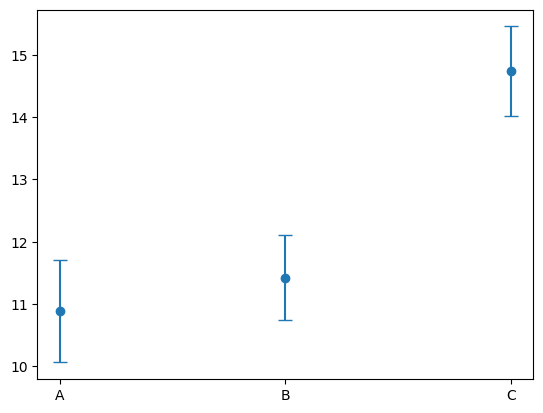

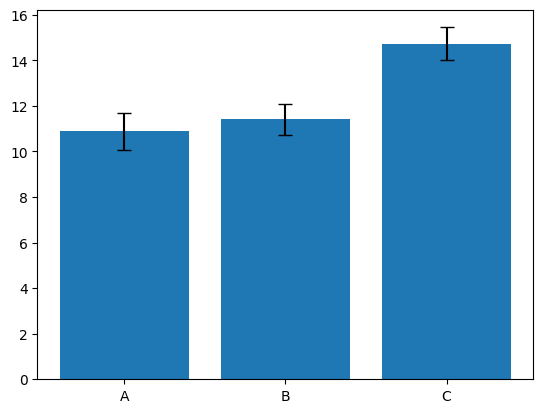

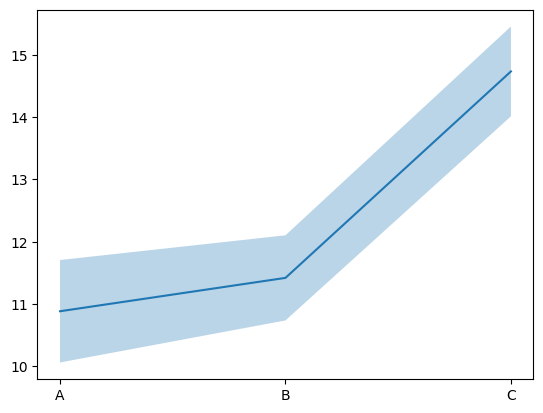

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

def ci_half(x):
    from scipy.stats import t
    mean = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(len(x))
    ci_low, ci_high = t.interval(0.95, df=len(x)-1, loc=mean, scale=se)   # simplest way to get confidence interval for given confidence
    ci_half = ci_high - mean  # use ci_half for plotting
    return ci_half

df = pd.DataFrame({
    'group': np.repeat(['A', 'B', 'C'], 30),
    'value': np.concatenate([
        np.random.normal(10, 2, 30),
        np.random.normal(12, 2, 30),
        np.random.normal(15, 2, 30)
    ])
})


summary = (
    df.groupby('group')['value']
      .agg(mean='mean', sem='sem', ci_half=ci_half)
)
# ci_halfs = df.groupby('group')['value'].apply(lambda l: ci_half(l))
# summary['ci_half'] = ci_halfs

print(summary)

plt.errorbar(
    summary.index,
    summary['mean'],
    yerr=summary['ci_half'],   # ← ONLY the SE
    fmt='o',
    capsize=5
)
plt.show()

plt.bar(
    summary.index,
    summary['mean'],
    yerr=summary['ci_half'],   # ← SE only
    capsize=5
)

plt.show()

plt.plot(summary.index, summary['mean'], label='Mean')

plt.fill_between(
    summary.index,
    summary['mean'] - summary['ci_half'],
    summary['mean'] + summary['ci_half'],
    alpha=0.3,
    label='± SE'
)

<Axes: xlabel='group', ylabel='value'>

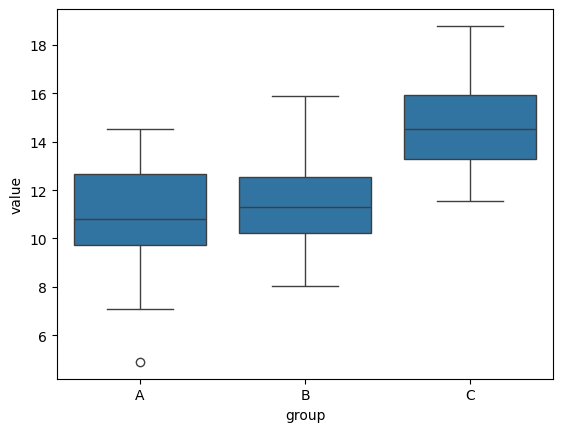

In [18]:
sns.boxplot(data=df, x='group', y='value')

In [19]:
from scipy.stats import t
x = df['value']
mean = np.mean(x)
se = np.std(x, ddof=1) / np.sqrt(len(x))
ci_low, ci_high = t.interval(0.95, df=len(x)-1, loc=mean, scale=se)   # simplest way to get confidence interval for given confidence
ci_half = ci_high - mean

print(ci_low, ci_high, ci_half)

11.799904187782726 12.892913940187821 0.5465048762025475


In [20]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 40  # per cell

rows = []

for gender in ['M', 'F']:
    for employment in ['employed', 'unemployed']:
        for married in [0, 1]:
            base = 50
            base += 10 if gender == 'M' else -10      # BIG gender effect
            base += 5 if employment == 'employed' else 0
            base += 3 if married == 1 else 0

            values = np.random.normal(base, 3, n)

            for v in values:
                rows.append({
                    'gender': gender,
                    'employment_status': employment,
                    'married': married,
                    'value': v
                })

df = pd.DataFrame(rows)
df.head()


,gender,employment_status,married,value
0,M,employed,0,66.490142
1,M,employed,0,64.585207
2,M,employed,0,66.943066
3,M,employed,0,69.569090
4,M,employed,0,64.297540


In [21]:
def ci_half(x):
    from scipy.stats import t
    mean = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(len(x))
    ci_low, ci_high = t.interval(0.95, df=len(x)-1, loc=mean, scale=se)   # simplest way to get confidence interval for given confidence
    ci_half = ci_high - mean  # use ci_half for plotting
    return ci_half

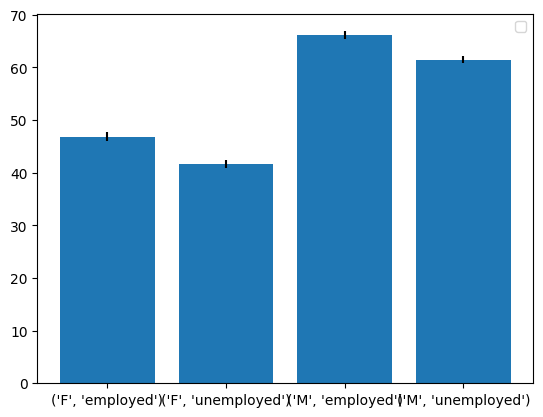

In [22]:
means = df.groupby(['gender', 'employment_status']).agg(mean=('value', 'mean'), ci_half=('value', ci_half))
plt.bar([str(t) for t in means.index], means['mean'], yerr=means['ci_half'])     #                            - stratified analysis on arbitrary fields
plt.legend()

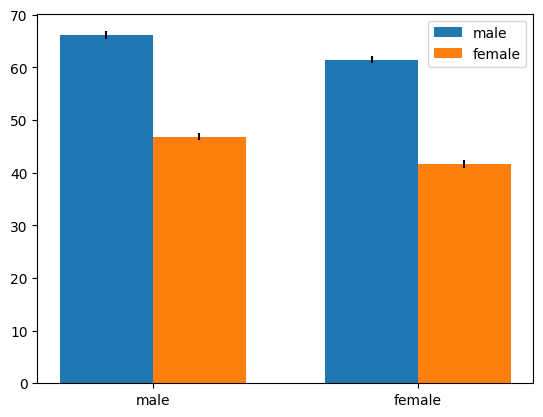

In [23]:
# means.index

# males_i = [i for i in means.index if i[0] == 'M']
# females_i = [i for i in means.index if i[0] == 'F']

# means[males]
males = means.loc[[i for i in means.index if i[0] == 'M']]
females = means.loc[[i for i in means.index if i[0] == 'F']]

x = np.arange(len(males))
width = 0.35
plt.bar(x - width/2, males['mean'], width, yerr=males['ci_half'], label='male')
plt.bar(x + width/2, females['mean'], width, yerr=males['ci_half'], label='female')
plt.xticks(x, ['male','female'])
plt.legend()

In [24]:
means.loc[('F', 'employed')]
means.loc['F'].loc['employed']

mean       46.883989
ci_half     0.783031
Name: employed, dtype: float64

In [25]:
contingency_table = pd.crosstab(        # crosstab to count all combinations
    df['gender'],
    df['employment_status']
)
chi2stat, p_value, _, _ = stats.chi2_contingency(contingency_table) # chi2 tests if two CATEGORICAL variables are independent using contingency table - rows/columns don't matter use pd.crosstab, H0: variables independent - low p_val=not independent
print(chi2stat, p_value)

0.0 1.0


In [26]:
X_dense = np.random.rand(100, 100)
X_dense[:, 2 * np.arange(50)] = 0

In [27]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import TruncatedSVD

docs = [
    "cats drink milk",
    "dogs chase cats",
    "milk comes from cows",
    "cars drive on roads",
    "roads have traffic and cars",
    "cats drink milk",
    "dogs chase cats",
    "milk comes from cows",
    "cars drive on roads",
    "roads have traffic and cars",
]

y = [0, 1, 0, 1, 1, 0, 1, 0, 1, 1]

# 1) TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

X = tfidf.fit_transform(docs)   # sparse (n_docs x n_terms)

print(X.shape)


svd = TruncatedSVD(n_components=4, random_state=0)


X_lsa = svd.fit_transform(X)    # dense (n_docs x k)

print("LSA doc vectors shape:", X_lsa.shape)
print(X_lsa)

print('word embeddings', svd.components_.shape)
word_embeddings = svd.components_

# print(word_embeddings.sape)

print(tfidf.get_feature_names_out())

logistic_regression = LogisticRegression()

X_train, X_test, y_train, y_test = train_test_split(X_lsa, y, test_size=0.3)

print(X_train.shape)

logistic_regression.fit(X_train, y_train)

preds = logistic_regression.predict(X_test)

print(accuracy_score(y_test, preds))

weights = logistic_regression.coef_

(10, 21)
LSA doc vectors shape: (10, 4)
[[-2.13272111e-16  7.72762790e-01  1.01041786e-16  6.34694943e-01]
 [ 3.17914556e-15  5.46425809e-01 -7.07106781e-01 -4.48797098e-01]
 [ 4.19047270e-15  5.46425809e-01  7.07106781e-01 -4.48797098e-01]
 [ 8.02315064e-01 -3.07194982e-15 -8.39908839e-17  3.51344564e-15]
 [ 8.02315064e-01 -2.65345318e-15 -6.85949680e-16  3.05352206e-15]
 [-2.13272111e-16  7.72762790e-01  1.01041786e-16  6.34694943e-01]
 [ 3.17914556e-15  5.46425809e-01 -7.07106781e-01 -4.48797098e-01]
 [ 4.19047270e-15  5.46425809e-01  7.07106781e-01 -4.48797098e-01]
 [ 8.02315064e-01 -3.07194982e-15 -8.39908839e-17  3.51344564e-15]
 [ 8.02315064e-01 -2.65345318e-15 -6.85949680e-16  3.05352206e-15]]
word embeddings (4, 21)
['cars' 'cars drive' 'cats' 'cats drink' 'chase' 'chase cats' 'comes'
 'comes cows' 'cows' 'dogs' 'dogs chase' 'drink' 'drink milk' 'drive'
 'drive roads' 'milk' 'milk comes' 'roads' 'roads traffic' 'traffic'
 'traffic cars']
(7, 4)
0.3333333333333333


In [28]:
G = nx.MultiDiGraph()

G.add_node('gal', age=10)
G.add_node('vid', age=30)
G.add_node('zarja', age=110)

G.add_edge('gal', 'vid', weight=1, loves=10)
G.add_edge('gal', 'vid', weight=1, loves=10)

for n in G.edges(keys=True):
    print(n)

('gal', 'vid', 0)
('gal', 'vid', 1)


In [29]:
weight_mapping = nx.get_edge_attributes(G, 'weight')
# G.get_edge_data('gal', 'vid')

In [30]:
nx.get_edge_attributes(G, 'weight')

{('gal', 'vid', 0): 1, ('gal', 'vid', 1): 1}

In [31]:
G['gal']['vid']

AtlasView({0: {'weight': 1, 'loves': 10}, 1: {'weight': 1, 'loves': 10}})

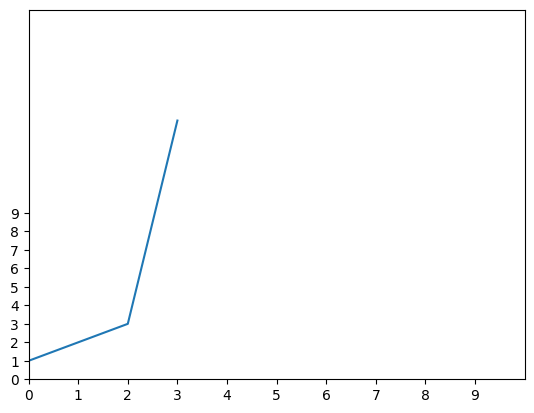

In [32]:
X = [1,2,3,14]

plt.plot(range(4), X)
plt.xlim(0, 10)
plt.ylim(0, 20)
plt.xticks(range(10));
plt.yticks(range(10));